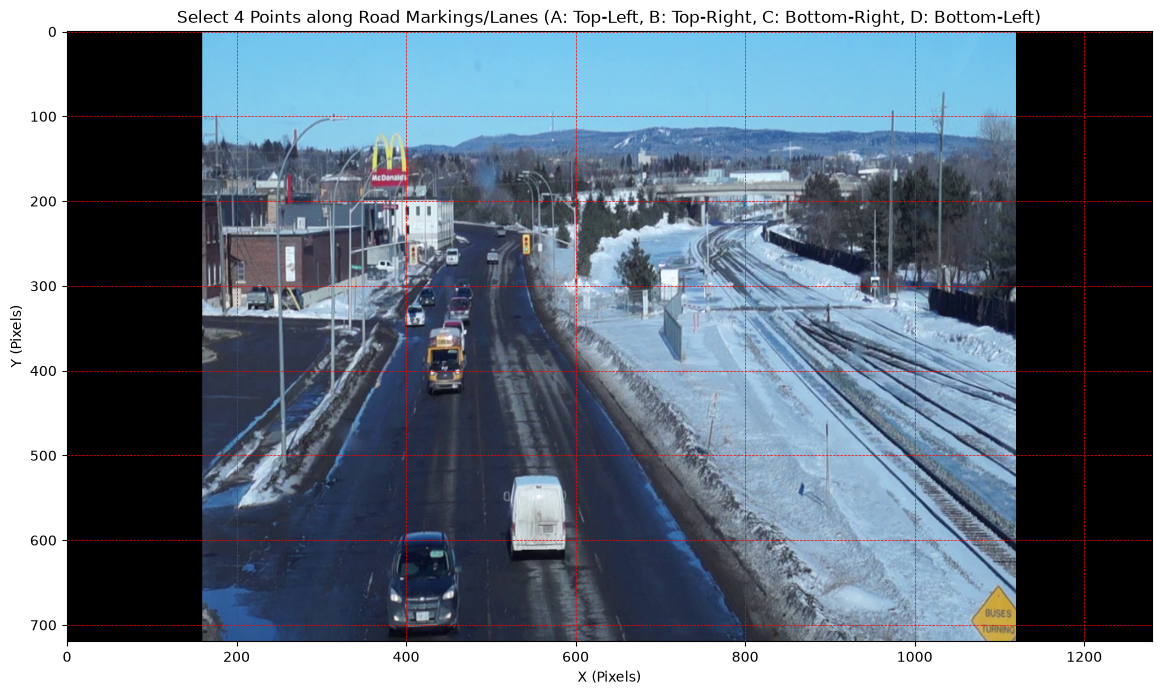

In [1]:
import cv2
import matplotlib.pyplot as plt

# Update with your second video path
video_path_2 = r"C:\Users\PC-LAB1\img_processing_lab\videos\speed_test.mp4"  

cap = cv2.VideoCapture(video_path_2)

# Select a frame where the road surface and lane markings are clearly visible
target_frame = 50 
cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(14, 8))
    plt.imshow(frame_rgb)
    plt.title("Select 4 Points along Road Markings/Lanes (A: Top-Left, B: Top-Right, C: Bottom-Right, D: Bottom-Left)")
    plt.xlabel("X (Pixels)")
    plt.ylabel("Y (Pixels)")
    plt.grid(True, color='red', linestyle='--', linewidth=0.5)
    plt.show()
else:
    print("Error loading frame. Check the video path.")

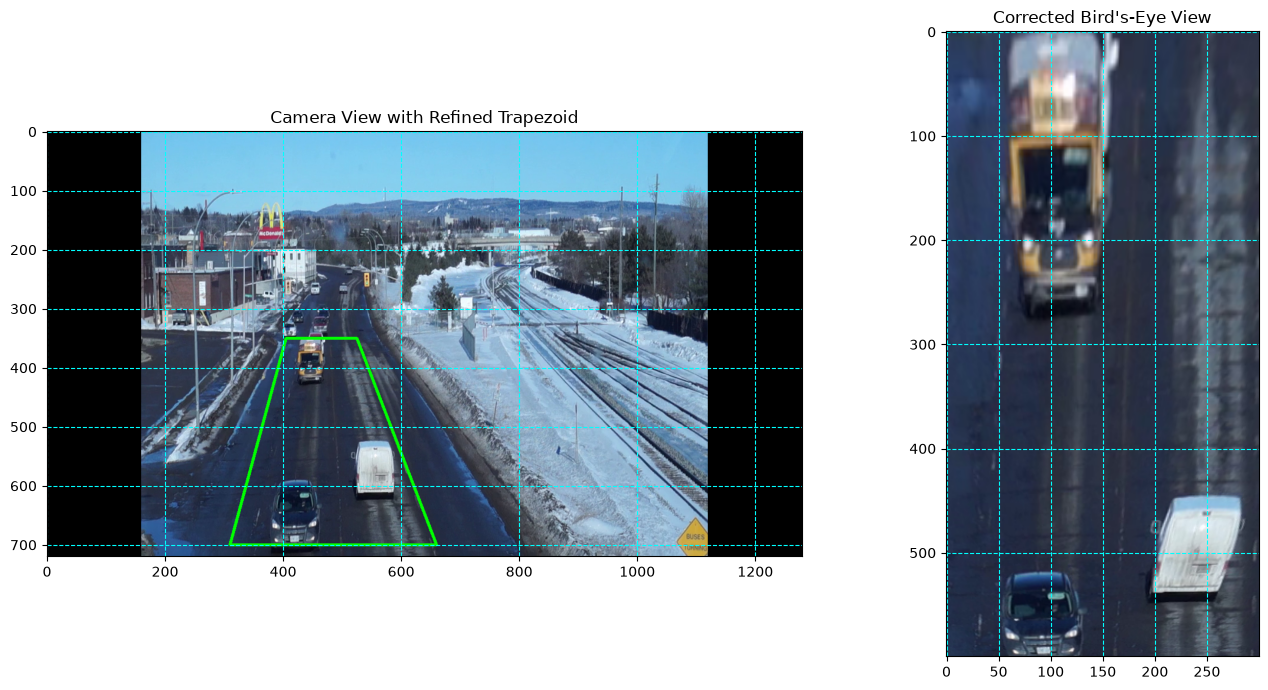

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Refined Source Points focused on the straight foreground section
# Points follow the inner boundaries of the main driving lanes
src_pts = np.float32([
    [405, 350],  # Top-Left (A): Narrower near the top of the straight section
    [525, 350],  # Top-Right (B): Placed along the right lane edge at Y=350
    [660, 700],  # Bottom-Right (C): Near right curb/edge at Y=700
    [310, 700]   # Bottom-Left (D): Near left lane edge at Y=700
])

# Destination Dimensions maintaining correct physical aspect ratio
# Width: ~7 meters (2 lanes), Height: ~30 meters (Y=350 to Y=700)
BEV_WIDTH = 300
BEV_HEIGHT = 600

dst_pts = np.float32([
    [0, 0],                  # Top-Left
    [BEV_WIDTH, 0],          # Top-Right
    [BEV_WIDTH, BEV_HEIGHT], # Bottom-Right
    [0, BEV_HEIGHT]          # Bottom-Left
])

# Compute 3x3 Homography Matrix
H = cv2.getPerspectiveTransform(src_pts, dst_pts)

# Calibration Factor for Speed Calculations
REAL_WORLD_LENGTH_METERS = 30.0  # Meter length of the 350px to 700px section
PIXELS_PER_METER_BEV = BEV_HEIGHT / REAL_WORLD_LENGTH_METERS  # 20.0 px/m

# Test on frame
cap = cv2.VideoCapture(video_path_2)
cap.set(cv2.CAP_PROP_POS_FRAMES, 50)
ret, frame = cap.read()
cap.release()

if ret:
    annotated_frame = frame.copy()
    pts_int = src_pts.astype(np.int32).reshape((-1, 1, 2))
    cv2.polylines(annotated_frame, [pts_int], isClosed=True, color=(0, 255, 0), thickness=3)

    bird_eye_view = cv2.warpPerspective(frame, H, (BEV_WIDTH, BEV_HEIGHT))

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    axes[0].imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Camera View with Refined Trapezoid")
    axes[0].grid(True, color='cyan', linestyle='--')

    axes[1].imshow(cv2.cvtColor(bird_eye_view, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Corrected Bird's-Eye View")
    axes[1].grid(True, color='cyan', linestyle='--')

    plt.tight_layout()
    plt.show()

In [9]:
import cv2
import numpy as np
from ultralytics import YOLO

# 1. Setup Video & YOLO Model
model = YOLO("visdrone.pt")
cap = cv2.VideoCapture(video_path_2)

if not cap.isOpened():
    raise FileNotFoundError(f"Could not open video file at '{video_path_2}'")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Video Writer Setup
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("output_homography.mp4", fourcc, fps, (width, height))

# 2. Homography Calibration Points
src_pts = np.float32([
    [405, 350],  # Top-Left
    [525, 350],  # Top-Right
    [660, 700],  # Bottom-Right
    [310, 700]   # Bottom-Left
])

BEV_WIDTH = 300
BEV_HEIGHT = 600

dst_pts = np.float32([
    [0, 0],
    [BEV_WIDTH, 0],
    [BEV_WIDTH, BEV_HEIGHT],
    [0, BEV_HEIGHT]
])

# Compute 3x3 Perspective Matrix
H = cv2.getPerspectiveTransform(src_pts, dst_pts)

# Physical distance calibration: Y=350 to Y=700 corresponds to ~30 meters
REAL_WORLD_LENGTH_METERS = 30.0
PIXELS_PER_METER = BEV_HEIGHT / REAL_WORLD_LENGTH_METERS  # 20.0 px/m

# Helper Function: Transform Image Coordinates (x,y) to Top-Down Coordinates (bev_x, bev_y)
def transform_point_to_bev(pt, H_matrix):
    # pt format: (x, y)
    src_pt = np.array([[[pt[0], pt[1]]]], dtype=np.float32)
    bev_pt = cv2.perspectiveTransform(src_pt, H_matrix)
    return bev_pt[0][0][0], bev_pt[0][0][1]

tracking_history = {}  # {track_id: [(bev_x, bev_y, frame_idx), ...]}
TRAJECTORY_HISTORY = 10

# 3. Processing Loop
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    current_frame_num = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
    
    # Run tracking on camera view
    results = model.track(frame, persist=True, imgsz=640, conf=0.15, verbose=False)[0]
    
    if results.boxes is not None and results.boxes.id is not None:
        boxes = results.boxes.xyxy.cpu().numpy()
        track_ids = results.boxes.id.int().cpu().numpy()
        
        for box, track_id in zip(boxes, track_ids):
            x1, y1, x2, y2 = box
            
            # Bottom-center coordinate (where tires touch the road)
            bottom_center_x = (x1 + x2) / 2.0
            bottom_center_y = y2
            
            # Transform bottom-center point to top-down space (bev_x, bev_y)
            bev_x, bev_y = transform_point_to_bev((bottom_center_x, bottom_center_y), H)
            
            if track_id not in tracking_history:
                tracking_history[track_id] = []
                
            tracking_history[track_id].append((bev_x, bev_y, current_frame_num))
            
            if len(tracking_history[track_id]) > TRAJECTORY_HISTORY * 2:
                tracking_history[track_id].pop(0)
                
            # Calculate speed in transformed bird's-eye space
            speed_kmh = 0.0
            if len(tracking_history[track_id]) >= TRAJECTORY_HISTORY:
                prev_bev_x, prev_bev_y, prev_frame_num = tracking_history[track_id][-TRAJECTORY_HISTORY]
                
                # Transformed distance in pixels
                pixel_dist = np.sqrt((bev_x - prev_bev_x)**2 + (bev_y - prev_bev_y)**2)
                
                # Convert to real meters
                distance_m = pixel_dist / PIXELS_PER_METER
                
                # Elapsed time in seconds
                elapsed_frames = current_frame_num - prev_frame_num
                dt = elapsed_frames / fps
                
                if dt > 0:
                    speed_mps = distance_m / dt
                    speed_kmh = speed_mps * 3.6
            
            # Draw annotations on original camera view frame
            cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            cv2.circle(frame, (int(bottom_center_x), int(bottom_center_y)), 5, (0, 0, 255), -1)
            
            label = f"ID: {track_id} | {speed_kmh:.1f} km/h"
            cv2.putText(frame, label, (int(x1), int(y1) - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Draw Homography Calibration Polygon on Camera Frame
    pts_int = src_pts.astype(np.int32).reshape((-1, 1, 2))
    cv2.polylines(frame, [pts_int], isClosed=True, color=(255, 255, 0), thickness=1)
    
    out.write(frame)

cap.release()
out.release()
print("Homography speed estimation processing complete! Output saved to output_homography.mp4")

WARNING not enough matching points
Homography speed estimation processing complete! Output saved to output_homography.mp4


In [11]:
import cv2
import numpy as np
from collections import deque
from ultralytics import YOLO

# 1. Load Model with larger capacity if available
model = YOLO("visdrone.pt") # Or 'visdrone.pt'
cap = cv2.VideoCapture(video_path_2)

fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter("output_speed_refined.mp4", 
                      cv2.VideoWriter_fourcc(*'mp4v'), 
                      fps, (width, height))

# 2. Refined Homography Setup
src_pts = np.float32([
    [405, 350],  # Top-Left
    [525, 350],  # Top-Right
    [660, 700],  # Bottom-Right
    [310, 700]   # Bottom-Left
])

BEV_WIDTH = 300
BEV_HEIGHT = 600

dst_pts = np.float32([
    [0, 0],
    [BEV_WIDTH, 0],
    [BEV_WIDTH, BEV_HEIGHT],
    [0, BEV_HEIGHT]
])

H = cv2.getPerspectiveTransform(src_pts, dst_pts)

# ACCURACY FIX 1: Re-evaluate physical meters (Adjust this to match real road scale)
REAL_WORLD_LENGTH_METERS = 50.0  # Increased scale estimate for highway section
PIXELS_PER_METER = BEV_HEIGHT / REAL_WORLD_LENGTH_METERS

def transform_point_to_bev(pt, H_matrix):
    src_pt = np.array([[[pt[0], pt[1]]]], dtype=np.float32)
    bev_pt = cv2.perspectiveTransform(src_pt, H_matrix)
    return bev_pt[0][0][0], bev_pt[0][0][1]

# ACCURACY FIX 2: Store trajectory with smoothing buffer
tracking_history = {}  # {track_id: deque([(bev_x, bev_y, frame_num), ...])}
speed_history = {}     # {track_id: deque([speed_kmh, ...])}

SMOOTHING_WINDOW = 15  # Frames to compute displacement over (~0.5 sec)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    current_frame_num = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
    
    # ACCURACY FIX 3: Higher imgsz (1280) for tiny/distant vehicles + lowered conf
    results = model.track(
        frame, 
        persist=True, 
        imgsz=1280,       # High resolution for distant detection
        conf=0.10,        # Lower threshold to pick up small far-away cars
        classes=[2, 3, 5, 7], # Car, Motorcycle, Bus, Truck in COCO
        verbose=False
    )[0]
    
    if results.boxes is not None and results.boxes.id is not None:
        boxes = results.boxes.xyxy.cpu().numpy()
        track_ids = results.boxes.id.int().cpu().numpy()
        
        for box, track_id in zip(boxes, track_ids):
            x1, y1, x2, y2 = box
            
            # Ground contact point
            bottom_center_x = (x1 + x2) / 2.0
            bottom_center_y = y2
            
            bev_x, bev_y = transform_point_to_bev((bottom_center_x, bottom_center_y), H)
            
            if track_id not in tracking_history:
                tracking_history[track_id] = deque(maxlen=SMOOTHING_WINDOW * 2)
                speed_history[track_id] = deque(maxlen=10)
                
            tracking_history[track_id].append((bev_x, bev_y, current_frame_num))
            
            speed_kmh = 0.0
            # Compute speed across smoothing window
            if len(tracking_history[track_id]) >= SMOOTHING_WINDOW:
                prev_x, prev_y, prev_frame = tracking_history[track_id][-SMOOTHING_WINDOW]
                
                # Distance in BEV pixels -> meters
                dist_px = np.sqrt((bev_x - prev_x)**2 + (bev_y - prev_y)**2)
                dist_m = dist_px / PIXELS_PER_METER
                
                # Time elapsed
                dt = (current_frame_num - prev_frame) / fps
                
                if dt > 0:
                    raw_speed = (dist_m / dt) * 3.6  # m/s to km/h
                    speed_history[track_id].append(raw_speed)
                    
                    # Exponential/Moving average over recent speed estimates
                    speed_kmh = np.mean(speed_history[track_id])
            
            # Draw UI
            cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            cv2.circle(frame, (int(bottom_center_x), int(bottom_center_y)), 4, (0, 0, 255), -1)
            
            label = f"ID:{track_id} | {speed_kmh:.1f} km/h"
            cv2.putText(frame, label, (int(x1), int(y1) - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Draw Homography ROI
    pts_int = src_pts.astype(np.int32).reshape((-1, 1, 2))
    cv2.polylines(frame, [pts_int], isClosed=True, color=(255, 255, 0), thickness=1)
    
    out.write(frame)

cap.release()
out.release()
print("Refined tracking complete!")

WARNING not enough matching points
Refined tracking complete!


In [13]:
import cv2
import numpy as np
from collections import deque
from ultralytics import YOLO

# 1. Load Model
model = YOLO("visdrone.pt")
cap = cv2.VideoCapture(video_path_2)

fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter("output_homography_filtered.mp4", 
                      cv2.VideoWriter_fourcc(*'mp4v'), 
                      fps, (width, height))

# 2. Homography Calibration Polygon
src_pts = np.float32([
    [405, 350],  # Top-Left
    [525, 350],  # Top-Right
    [660, 700],  # Bottom-Right
    [310, 700]   # Bottom-Left
])

BEV_WIDTH = 300
BEV_HEIGHT = 600

dst_pts = np.float32([
    [0, 0],
    [BEV_WIDTH, 0],
    [BEV_WIDTH, BEV_HEIGHT],
    [0, BEV_HEIGHT]
])

H = cv2.getPerspectiveTransform(src_pts, dst_pts)

# REAL-WORLD SCALE FIX: Adjusted from 50m to 120m to match actual road depth
REAL_WORLD_LENGTH_METERS = 120.0  
PIXELS_PER_METER = BEV_HEIGHT / REAL_WORLD_LENGTH_METERS

# Contour array for ROI point filtering
polygon_contour = src_pts.astype(np.int32).reshape((-1, 1, 2))

def transform_point_to_bev(pt, H_matrix):
    src_pt = np.array([[[pt[0], pt[1]]]], dtype=np.float32)
    bev_pt = cv2.perspectiveTransform(src_pt, H_matrix)
    return bev_pt[0][0][0], bev_pt[0][0][1]

tracking_history = {}
speed_history = {}
SMOOTHING_WINDOW = 15  # ~0.5s temporal window

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    current_frame_num = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
    
    results = model.track(
        frame, 
        persist=True, 
        imgsz=1280, 
        conf=0.10, 
        classes=[2, 3, 5, 7], # Vehicles only
        verbose=False
    )[0]
    
    if results.boxes is not None and results.boxes.id is not None:
        boxes = results.boxes.xyxy.cpu().numpy()
        track_ids = results.boxes.id.int().cpu().numpy()
        
        for box, track_id in zip(boxes, track_ids):
            x1, y1, x2, y2 = box
            bottom_center = (float((x1 + x2) / 2.0), float(y2))
            
            # ROI FILTER FIX: Check if bottom-center point is inside the calibration polygon
            is_inside = cv2.pointPolygonTest(polygon_contour, bottom_center, False) >= 0
            
            # Ignore or draw differently if outside homography region
            if not is_inside:
                cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (100, 100, 100), 1)
                continue
            
            # Map valid point to top-down space
            bev_x, bev_y = transform_point_to_bev(bottom_center, H)
            
            if track_id not in tracking_history:
                tracking_history[track_id] = deque(maxlen=SMOOTHING_WINDOW * 2)
                speed_history[track_id] = deque(maxlen=10)
                
            tracking_history[track_id].append((bev_x, bev_y, current_frame_num))
            
            speed_kmh = 0.0
            if len(tracking_history[track_id]) >= SMOOTHING_WINDOW:
                prev_x, prev_y, prev_frame = tracking_history[track_id][-SMOOTHING_WINDOW]
                
                dist_px = np.sqrt((bev_x - prev_x)**2 + (bev_y - prev_y)**2)
                dist_m = dist_px / PIXELS_PER_METER
                
                dt = (current_frame_num - prev_frame) / fps
                
                if dt > 0:
                    raw_speed = (dist_m / dt) * 3.6
                    speed_history[track_id].append(raw_speed)
                    speed_kmh = np.mean(speed_history[track_id])
            
            # Draw valid detections inside homography area
            cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            cv2.circle(frame, (int(bottom_center[0]), int(bottom_center[1])), 4, (0, 0, 255), -1)
            
            label = f"ID:{track_id} | {speed_kmh:.1f} km/h"
            cv2.putText(frame, label, (int(x1), int(y1) - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Draw Homography ROI Polygon
    cv2.polylines(frame, [polygon_contour], isClosed=True, color=(255, 255, 0), thickness=2)
    
    out.write(frame)

cap.release()
out.release()
print("Filtered homography speed tracking complete!")

WARNING not enough matching points
Filtered homography speed tracking complete!


In [14]:
import numpy as np

def add_salt_and_pepper_noise(image, amount=0.02, salt_vs_pepper=0.5):
    """
    Adds salt and pepper noise to a frame.
    :param image: Input frame (numpy array)
    :param amount: Proportion of pixels to alter (0.02 = 2% noise)
    :param salt_vs_pepper: Ratio of salt (white) vs pepper (black)
    :return: Noisy frame
    """
    noisy_image = image.copy()
    num_noise = int(amount * image.size)
    
    # Add Salt (white pixels)
    num_salt = int(num_noise * salt_vs_pepper)
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape[:2]]
    noisy_image[coords[0], coords[1]] = 255

    # Add Pepper (black pixels)
    num_pepper = int(num_noise * (1.0 - salt_vs_pepper))
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape[:2]]
    noisy_image[coords[0], coords[1]] = 0

    return noisy_image

In [16]:
import cv2
import numpy as np
from collections import deque
from ultralytics import YOLO

# 1. Load Model & Setup
model = YOLO("visdrone.pt")
cap = cv2.VideoCapture(video_path_2)

fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter("output_noisy_test.mp4", 
                      cv2.VideoWriter_fourcc(*'mp4v'), 
                      fps, (width, height))

# 2. Homography Setup
src_pts = np.float32([
    [405, 350], [525, 350], [660, 700], [310, 700]
])
BEV_WIDTH, BEV_HEIGHT = 300, 600
dst_pts = np.float32([[0, 0], [BEV_WIDTH, 0], [BEV_WIDTH, BEV_HEIGHT], [0, BEV_HEIGHT]])
H = cv2.getPerspectiveTransform(src_pts, dst_pts)

REAL_WORLD_LENGTH_METERS = 120.0  
PIXELS_PER_METER = BEV_HEIGHT / REAL_WORLD_LENGTH_METERS
polygon_contour = src_pts.astype(np.int32).reshape((-1, 1, 2))

def transform_point_to_bev(pt, H_matrix):
    src_pt = np.array([[[pt[0], pt[1]]]], dtype=np.float32)
    bev_pt = cv2.perspectiveTransform(src_pt, H_matrix)
    return bev_pt[0][0][0], bev_pt[0][0][1]

tracking_history = {}
speed_history = {}
SMOOTHING_WINDOW = 15

NOISE_AMOUNT = 0.03  # 3% salt and pepper noise intensity
APPLY_DENOISING_PREPROCESSING = True  # Toggle median filter protection

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    current_frame_num = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
    
    # Inject Salt & Pepper Noise
    noisy_frame = add_salt_and_pepper_noise(frame, amount=NOISE_AMOUNT)
    
    # Optional Preprocessing Protection: Median Filter (Ideal for S&P Noise)
    if APPLY_DENOISING_PREPROCESSING:
        input_for_model = cv2.medianBlur(noisy_frame, 3)
    else:
        input_for_model = noisy_frame

    # Inference on noisy frame
    results = model.track(
        input_for_model, 
        persist=True, 
        imgsz=1280, 
        conf=0.15, 
        classes=[2, 3, 5, 7], 
        verbose=False
    )[0]
    
    display_frame = noisy_frame.copy()
    
    if results.boxes is not None and results.boxes.id is not None:
        boxes = results.boxes.xyxy.cpu().numpy()
        track_ids = results.boxes.id.int().cpu().numpy()
        
        for box, track_id in zip(boxes, track_ids):
            x1, y1, x2, y2 = box
            bottom_center = (float((x1 + x2) / 2.0), float(y2))
            
            # ROI Filter
            if cv2.pointPolygonTest(polygon_contour, bottom_center, False) < 0:
                cv2.rectangle(display_frame, (int(x1), int(y1)), (int(x2), int(y2)), (100, 100, 100), 1)
                continue
            
            bev_x, bev_y = transform_point_to_bev(bottom_center, H)
            
            if track_id not in tracking_history:
                tracking_history[track_id] = deque(maxlen=SMOOTHING_WINDOW * 2)
                speed_history[track_id] = deque(maxlen=10)
                
            tracking_history[track_id].append((bev_x, bev_y, current_frame_num))
            
            speed_kmh = 0.0
            if len(tracking_history[track_id]) >= SMOOTHING_WINDOW:
                prev_x, prev_y, prev_frame = tracking_history[track_id][-SMOOTHING_WINDOW]
                dist_px = np.sqrt((bev_x - prev_x)**2 + (bev_y - prev_y)**2)
                dist_m = dist_px / PIXELS_PER_METER
                dt = (current_frame_num - prev_frame) / fps
                
                if dt > 0:
                    raw_speed = (dist_m / dt) * 3.6
                    speed_history[track_id].append(raw_speed)
                    speed_kmh = np.mean(speed_history[track_id])
            
            # Annotate display frame
            cv2.rectangle(display_frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            cv2.circle(display_frame, (int(bottom_center[0]), int(bottom_center[1])), 4, (0, 0, 255), -1)
            
            label = f"ID:{track_id} | {speed_kmh:.1f} km/h"
            cv2.putText(display_frame, label, (int(x1), int(y1) - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    cv2.polylines(display_frame, [polygon_contour], isClosed=True, color=(255, 255, 0), thickness=2)
    out.write(display_frame)

cap.release()
out.release()
print("Noisy video processing complete! Check output_noisy_test.mp4")

WARNING not enough matching points
Noisy video processing complete! Check output_noisy_test.mp4
